from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.chdir(PROJECT_ROOT)

from config import BASE_DATA_DIR, KAGGLE_DATASET_URLS
from get_kaggle import get_data_from_kaggle


In [ ]:
# Optional: download fresh Kaggle files if you have kaggle.json configured locally.
# The small CSV files used for this portfolio version are already included in data/raw/.
# get_data_from_kaggle(BASE_DATA_DIR, KAGGLE_DATASET_URLS)


In [2]:
get_data_from_kaggle(BASE_DATA_DIR, KAGGLE_DATASET_URLS)

Dataset URL: https://www.kaggle.com/datasets/henriupton/wind-power-production-us-2001-2023
License(s): other
Dataset URL: https://www.kaggle.com/datasets/sujaykapadnis/tornados
License(s): other
Finished downloading and extracting datasets.


In [3]:
from get_data import run_all_data_cleaning_and_merge
wind_df, tornados_df, merged_df = run_all_data_cleaning_and_merge()

# 1. Historical Wind Production Analysis

In [4]:
from data_analysis import analysis_one_a,plot_bottom5_states,analysis_one_b

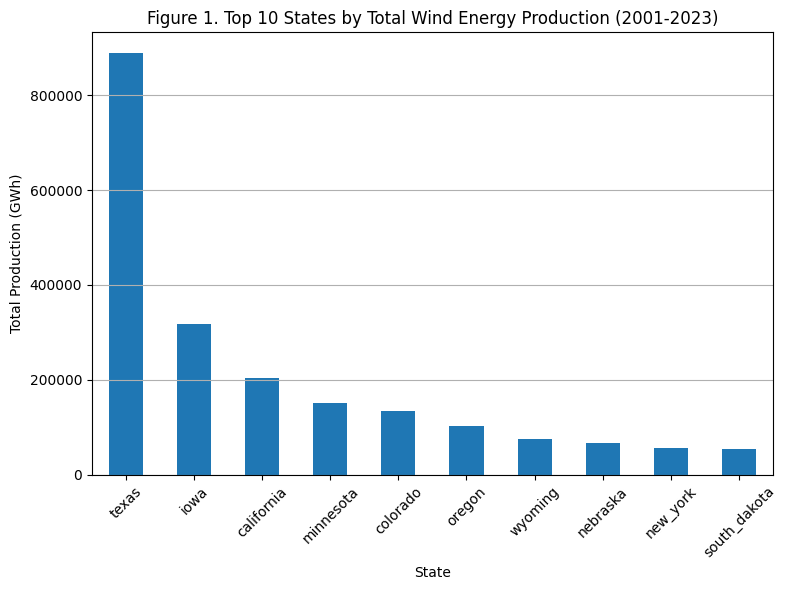

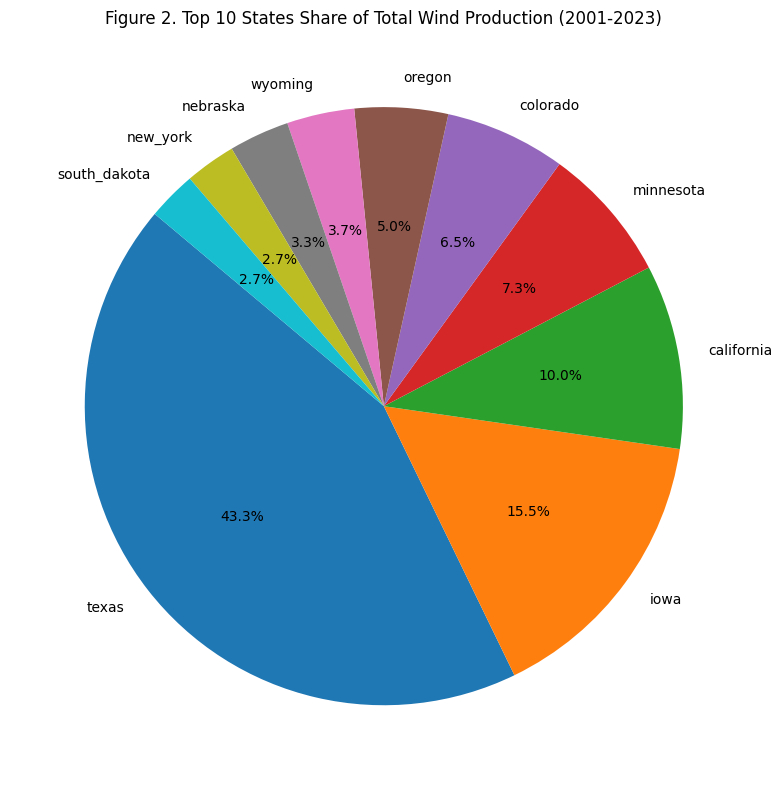

In [5]:
analysis_one_a(wind_df)

## Figures 1 and 2: Identify the top 10 states by total wind energy production and visualize their contribution as a pie chart.
### - The top 10 states by total wind production are Texas, Iowa, California, Minnesota, Colorado, Oregon, Wyoming, Nebraska, New York, and South Dakota.
### - Texas dominates the figure with more than 850,000 GWh of the total wind energy production, and accounts for 43.3% of the total wind production out of the 10 states, and is more than double the amount produced by the second-highest state, Iowa. 
### - Iowa and California account for 15.5% and 10.0% of the 10 states in the second and third places.

In [ ]:
plot_bottom5_states(wind_df)

## Figure 3: Identify the bottom five states by total wind energy production
### - According to Figure 3, South Dakota, Pennsylvania, Wisconsin, Hawaii, and Vermont are the bottom five states by total wind energy production, and Hawaii and Vermont show very minimal wind energy production.

In [ ]:
analysis_one_b(wind_df)

## Figures 4 and 5: Identify the top 5 fastest-growing states and their growing trends 
### - Texas shows a dramatic lead in growth over the other top 4 states, and Iowa, Oklahoma, Kansas, and Illinois also show a strong upward trend
### - All states exhibit seasonal variability

# 2. Tornado Frequency and Magnitude Analysis

In [ ]:
from data_analysis import analysis_tornadoes

In [ ]:
analysis_tornadoes(tornados_df)

## Figures 6 and 7: shows the total number of tornado events per state, and the top 5 states tornado counts by magnitude
### - Texas has the highest number of tornado events, with more than 3,000 recorded tornadoes, followed by Florida (FL), Kansas (KS), Oklahoma (OK), and Nebraska (NE)
### - Magnitude 0 (light blue) tornadoes are the most common across all top states, reflecting the low intensity of many tornadoes.
### - All the top 5 states show a similar distribution pattern with fewer magnitude 3 tornadoes.

# 3. Correlation and Clustering of Wind Speed, Potential Yield, and Tornado Disaster Data

In [ ]:
from data_analysis import plot_correlation_matrix, plot_potential_vs_windspeed_disaster,analysis_three_cluster

In [ ]:
plot_correlation_matrix(merged_df)

## Figure 8: Heatmap shows linear correlations between wind speed, potential capacity, and tornado counts.
### - Average Wind Speed vs Potential Wind Capacity (Correlation: 0.30) indicates a moderate positive relationship with higher wind speeds tend to have greater potential wind capacity, but other factors likely influence capacity planning.
### - Potential Wind Capacity vs Tornadoes Disasters (Correlation: 0.55) indicates the strongest relationship and suggests that areas with high potential for wind energy also tend to experience more tornado events. 
### - Average Wind Speed vs Tornadoes Disasters (Correlation: 0.048) indicates a very weak correlation, implying that wind speed alone does not correlate with tornado frequency at the state level.

In [ ]:
plot_potential_vs_windspeed_disaster(merged_df)

## Figure 9: Regression plot of potential wind yield vs average wind speed.
### - This scatter plot with a regression line shows a positive correlation between average wind speed and potential wind capacity.
### - As wind speed increases, the potential capacity also tends to increase, though the spread of points indicates there is some variation due to other factors 
## Figure 10: Regression plot of potential wind yield vs tornado disasters.
### - This scatter plot with a regression line shows a moderate to strong positive correlation between tornado disaster frequency and potential wind capacity.
### - States with the highest wind capacity (e.g., Texas, Oklahoma, and Kansas) also experience a higher number of tornado events.

In [ ]:
analysis_three_cluster(merged_df, n_clusters=3)

## Figure 11: Uses the Elbow Method to identify the optimal number of clusters for state-level grouping based on wind and disaster metrics.
### - Using the Elbow Method, this plot helps determine the optimal number of clusters for K-Means clustering, which evaluates how the total within-cluster variance (inertia) decreases as the number of clusters increases.
### - The "elbow" point appears around k = 3 or k = 4. This is where the reduction in inertia starts to level off.
### - As result, I picked k = 3 for K-means clustering

## Figures 12 and 13: Implements KMeans clustering (default n_clusters=3) to classify states based on: Average Wind Speed, Potential Wind Capacity, Tornado Disaster Frequency

### Figure 12: This scatterplot uses Average Wind Speed (x-axis) and Potential Wind Capacity (y-axis) to display the clusters identified using K-Means (with k = 3).
### - Cluster 2 (blue) includes states with high potential wind capacity and generally moderate to high wind speeds. 
### - Cluster 1 (orange) includes states with moderate wind speeds and capacity.
### - Cluster 0 (green) features states with lower wind speeds and capacity.
### Figure 13: This scatterplot uses Tornado Disasters (x-axis) and Potential Wind Capacity (y-axis) to display the clusters identified using K-Means (with k = 3).
### - Cluster 2 (blue) again shows the highest wind potential and tends to have higher tornado frequencies.
### - Cluster 0 (green) states experience both low disaster frequency and low capacity.
### - Cluster 1 (orange) forms a middle ground with moderate disaster risk and potential.

## According to K-means clustering: States in Cluster 2: ['Arizona', 'Kansas', 'Montana', 'Nebraska', 'Nevada', 'New Mexico', 'Texas', 'Wyoming']
### - These states are characterized by: High potential wind capacity, Moderate to high average wind speeds, Frequent tornado disaster occurrences (especially in Texas, Kansas, and Nebraska)
### - This cluster likely represents regions that are: Highly favorable for wind energy development due to strong wind resources, and exposed to higher climate and disaster risks, particularly tornadoes